# Social Network Analysis
The positive interaction layer encompasses 100 states out of 195 states and observer states, with 148 edges and a total positive sentiment score of 54.566. The average sentiment score of 0.369 indicates moderately positive interactions among states overall. 

In [19]:
import pandas as pd
import networkx as nx
import random
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

random.seed(42)
np.random.seed(42)

In [35]:
# info
df = pd.read_csv('../data/layer1/layer1_backbone_pos.csv')

G = nx.Graph()

for _, row in df.iterrows():
    G.add_edge(row['s1'], row['s2'], weight=row['avg_score'])

num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
total_weight = sum([d['weight'] for u, v, d in G.edges(data=True)])
avg_weight = total_weight/num_edges

# weighted degree (strength) average
weighted_degrees = [G.degree(n, weight='weight') for n in G.nodes()]
avg_weighted_degree = sum(weighted_degrees) / num_nodes

print(f"Nodes: {num_nodes}")
print(f"Edges: {num_edges}")
print(f"Strength: {total_weight:.4f}")
print(f"Average edge weight: {avg_weight:.4f}")
print(f"Average weighted degree (strength): {avg_weighted_degree:.4f}")


Nodes: 100
Edges: 148
Strength: 54.5662
Average edge weight: 0.3687
Average weighted degree (strength): 1.0913


# Network Assessment
With regard to cohesion, the layer presented an extremely low density (D_obs = 0.030) compared to ATOP alliance networks (D = 0.246) , while exhibiting a high transitivity (T_obs=0.1705, T_exp=0.042, p<0.001). In other words, only 3% of all possible state connections were realized, yet existing connections tend to cluster around bilateral cooperations. The endogeneity reflected by high transitivity is explained by Kinne (2013) as a mechanism for reducing risks and increasing gains. For any two states, a shared partner provides information to both, while creating a more durable and stable club through triadic structures. Accordingly, the generally sparse yet locally cohesive layer reflects states’ cautious and conservative approach to positive interactions. In terms of efficiency, the layer exhibits a long mean distance (MD_obs = 4.826, MD_exp = 4.067, p < 0.001), a long diameter (Dia_obs = 12, Dia_exp = 9.372, p < 0.033) and a low global efficiency (G_obs = 0.243, G_exp = 0.265, p < 0.053). Although the low efficiency hinders information dissemination, it protects collaborations by impeding infiltrators entering clusters and disrupting existing collaborations, thereby reducing the risk of betrayal by unfamiliar members (Cassar, 2007). In conclusion, the layer is globally fragmented while connected closely within local clusters, sacrificing overall efficiency and connectivity in favor of security and stability.


In [8]:
def network_measures(G):
    density = nx.density(G)
    transitivity = nx.transitivity(G)
    # in case that the shortest path is infinite if the network is not connected
    if nx.is_connected(G):
        mean_distance = nx.average_shortest_path_length(G)
        diameter = nx.diameter(G)
    else:
        largest_cc = max(nx.connected_components(G), key=len)
        subgraph = G.subgraph(largest_cc)
        mean_distance = nx.average_shortest_path_length(subgraph)
        diameter = nx.diameter(subgraph)
    global_eff = nx.global_efficiency(G)
    return density, transitivity, mean_distance, diameter, global_eff

metrics = network_measures(G)
print(f"Density: {metrics[0]:.3f}")
print(f"Transitivity: {metrics[1]:.3f}")
print(f"Mean Distance: {metrics[2]:.3f}")
print(f"Diameter: {metrics[3]}")
print(f"Global Efficiency: {metrics[4]:.3f}")


Density: 0.030
Transitivity: 0.171
Mean Distance: 4.826
Diameter: 12
Global Efficiency: 0.243


In [10]:
def config_permutation_network_measures(G, n_perm=1000):
    degree_seq = [d for n, d in G.degree()]
    results = {'density': [], 'transitivity': [], 'mean_distance': [], 'diameter': [], 'global_efficiency': []}
    for _ in range(n_perm):
        # Configuration model
        G_conf = nx.configuration_model(degree_seq)
        G_conf = nx.Graph(G_conf)
        G_conf.remove_edges_from(nx.selfloop_edges(G_conf))
        density, transitivity, mean_distance, diameter, global_eff = network_measures(G_conf)
        results['density'].append(density)
        results['transitivity'].append(transitivity)
        results['mean_distance'].append(mean_distance)
        results['diameter'].append(diameter)
        results['global_efficiency'].append(global_eff)
    for k in results:
        results[k] = np.array(results[k]) # type:ignore
    return results

config_results = config_permutation_network_measures(G, n_perm=1000)

obs_density, obs_trans, obs_mean_dist, obs_diam, obs_eff = network_measures(G)

p_density = (np.sum(config_results['density'] >= obs_density) + 1) / (len(config_results['density']) + 1)
p_trans = (np.sum(config_results['transitivity'] >= obs_trans) + 1) / (len(config_results['transitivity']) + 1) # type:ignore
p_mean_dist = (np.sum(config_results['mean_distance'] >= obs_mean_dist) + 1) / (len(config_results['mean_distance']) + 1) # type:ignore
p_diam = (np.sum(config_results['diameter'] >= obs_diam) + 1) / (len(config_results['diameter']) + 1) # type:ignore
p_eff = (np.sum(config_results['global_efficiency'] <= obs_eff) + 1) / (len(config_results['global_efficiency']) + 1) # type:ignore

print(f'Density p-value: {p_density:.3f}')
print(f'Transitivity p-value: {p_trans:.3f}')
print(f'Mean distance p-value: {p_mean_dist:.3f}')
print(f'Diameter p-value: {p_diam:.3f}')
print(f'Global efficiency p-value: {p_eff:.3f}')


Density p-value: 0.006
Transitivity p-value: 0.001
Mean distance p-value: 0.001
Diameter p-value: 0.033
Global efficiency p-value: 0.053


In [11]:
print(f'Density permutation mean: {config_results["density"].mean():.3f}') # type:ignore
print(f'Transitivity permutation mean: {config_results["transitivity"].mean():.3f}') # type:ignore
print(f'Mean_distance permutation mean: {config_results["mean_distance"].mean():.3f}') # type:ignore
print(f'Diameter permutation mean: {config_results["diameter"].mean():.3f}') # type:ignore
print(f'Global_efficiency permutation mean: {config_results["global_efficiency"].mean():.3f}') # type:ignore

Density permutation mean: 0.029
Transitivity permutation mean: 0.042
Mean_distance permutation mean: 4.067
Diameter permutation mean: 9.372
Global_efficiency permutation mean: 0.265


# Community Detection
The detected communities further quantify and reinforce this conclusion. A total of 13 communities (Appendix A) constitute the entire network with a modularity of 0.703, suggesting a pronounced and unusually strong community structure. Within communities, nodes are closely connected and edges carry higher sentiment scores, as illustrated in Figure 1 and Figure 2. However, between communities states are rarely linked, as further evidenced by the weighted EI Index. The global index is -0.665, while each community's index ranges from -0.139 to -1.000, indicating pervasive inward-cohesiveness across all communities. From a perspective of structure, the positive interaction layer aligns with a polycentric pattern (Kim, 2020), characterized by high modularity and multiple fragmented communities. In the meantime, it also aligns with the theoretical concept of polycentric system. In this layer, communities operate as autonomous units while remaining responsive to others through multiple forms of interactions such as cooperation (Carlisle & Gruby, 2019). The system is featured by communities with “overlapping mandates, ambiguous hierarchies of authority, and no ultimate arbiter”; nevertheless, it can function fluidly in an ordered chaos (Koinova et al., 2021), which can be attributed to its structural redundancy. This feature is also connected with the high transitivity  that offers alternative paths for cooperation to circumvent disruptions to the entire network, enhancing its resilience against risks (Carlisle & Gruby, 2019). The polycentric system reflected by communities captures emerging tendencies of the world political landscape, while corresponding to its macro structural properties such as low density and high transitivity. 

In [13]:
communities = nx.community.louvain_communities(G, weight='weight', seed=42)
partition = {}
for i, comm in enumerate(communities):
    for node in comm:
        partition[node] = i
modularity = nx.community.modularity(G, communities, weight='weight')

print(f"Detected communities: {len(communities)}")
print(f"Weighted modularity: {modularity:.3f}")

Detected communities: 13
Weighted modularity: 0.703


In [27]:
def calculate_weighted_ei(G, partition):
    total_w_internal = 0
    total_w_external = 0
    
    community_ids = sorted(list(set(partition.values())))
    comm_stats = {cid: {'I_w': 0, 'E_w': 0} for cid in community_ids}

    for u, v, d in G.edges(data=True):
        weight = d.get('weight', 1.0)
        comm_u = partition[u]
        comm_v = partition[v]
        
        if comm_u == comm_v:
            total_w_internal += weight
            comm_stats[comm_u]['I_w'] += weight
        else:
            total_w_external += weight
            comm_stats[comm_u]['E_w'] += weight
            comm_stats[comm_v]['E_w'] += weight

    # (E - I) / (E + I)
    global_weighted_ei = (total_w_external - total_w_internal) / (total_w_external + total_w_internal)
    
    details = []
    for cid in community_ids:
        Iw = comm_stats[cid]['I_w']
        Ew = comm_stats[cid]['E_w']
        ei_local = (Ew - Iw) / (Ew + Iw) if (Ew + Iw) > 0 else 0
        comm_size = list(partition.values()).count(cid)
        details.append({
            'Community': f"Comm {cid}",
            'Size':comm_size,
            'Internal_Weight_Sum': Iw,
            'External_Weight_Sum': Ew,
            'Weighted_EI': ei_local
        })

    df_details = pd.DataFrame(details)
    
    print(f"=== Global Weighted E-I Analysis ===")
    print(f"Total Internal Weight (I): {total_w_internal:.3f}")
    print(f"Total External Weight (E): {total_w_external:.3f}")
    print(f"Global Weighted E-I Index: {global_weighted_ei:.3f}")
    print("=====================================")
    
    return global_weighted_ei, df_details

global_wei, df_wei = calculate_weighted_ei(G, partition)
print(df_wei)

=== Global Weighted E-I Analysis ===
Total Internal Weight (I): 45.416
Total External Weight (E): 9.151
Global Weighted E-I Index: -0.665
   Community  Size  Internal_Weight_Sum  External_Weight_Sum  Weighted_EI
0     Comm 0    13             8.171524             2.514444    -0.529393
1     Comm 1     2             0.121290             0.000000    -1.000000
2     Comm 2    17             5.810409             4.029469    -0.180992
3     Comm 3    11             6.836957             3.691457    -0.298763
4     Comm 4     2             0.333333             0.090909    -0.571429
5     Comm 5    10             4.283333             0.285714    -0.874935
6     Comm 6    10             7.500000             1.535714    -0.660079
7     Comm 7    12             5.640863             3.058058    -0.296911
8     Comm 8     3             0.229010             0.000000    -1.000000
9     Comm 9     4             0.616667             0.309524    -0.331620
10   Comm 10     3             2.000000         

## (permutation for global EI)
I intended to do permutation tests for this metric. However, as it is a weighed network, I came across a problem of weight allocation. AI suggested to randomly allocate existing weights to edges, however, the num of generated edges in configuration model does not amount to the original network...So I gave up the idea as the Q is already quite high. In addition, I will just report the result avoiding using descriptive words such as 'high'.

In [24]:
# permutation
# def config_permutation_ei_test(G, observer_partition, degree_seq, n_perm=1000):
#     """
#     EI Index Permutation Test on Configuration Models
#     I kept the original community labels while only allocate to different nodes randomly.
#     Weights are sampled from the original graph distribution.
#     """
#     nodes_original = list(G.nodes())
#     community_ids_obs = sorted(list(set(observer_partition.values())))
#     comm_sizes = [list(observer_partition.values()).count(cid) for cid in community_ids_obs]
   
#     obs_global_ei, _ = calculate_weighted_ei_global_only(G, observer_partition)
    
#     # Extract weights from original graph for resampling
#     original_weights = [d['weight'] for u, v, d in G.edges(data=True)]
#     num_edges_original = len(original_weights)
    
#     ei_results = []
    
#     for perm_idx in range(n_perm):
#         G_conf = nx.configuration_model(degree_seq)
#         G_conf = nx.Graph(G_conf)
#         G_conf.remove_edges_from(nx.selfloop_edges(G_conf))
        
#         node_mapping = {i: nodes_original[i] for i in range(len(nodes_original))}
#         G_conf = nx.relabel_nodes(G_conf, node_mapping)
        
#         # Resample weights from original distribution to match G_conf edge count
#         num_edges_conf = G_conf.number_of_edges()
#         resampled_weights = np.random.choice(original_weights, size=num_edges_conf, replace=True)
        
#         G_conf_edges = list(G_conf.edges())
#         for i, (u, v) in enumerate(G_conf_edges):
#             G_conf[u][v]['weight'] = resampled_weights[i]
        
#         random_labels = []
#         comm_id = 0
#         for size in comm_sizes:
#             random_labels.extend([comm_id] * size)
#             comm_id += 1
#         random.shuffle(random_labels)
        
#         random_partition = {nodes_original[i]: random_labels[i] for i in range(len(nodes_original))}
        
#         perm_global_ei, _ = calculate_weighted_ei_global_only(G_conf, random_partition)
#         ei_results.append(perm_global_ei)
    
#     ei_results = np.array(ei_results)
    
#     p_ei = (np.sum(ei_results <= obs_global_ei) + 1) / (len(ei_results) + 1)
    
#     print(f"\n=== EI Index Permutation Test (Config Model + Random Labels + Resampled Weights) ===")
#     print(f"Observed Global EI: {obs_global_ei:.3f}")
#     print(f"Permutation Mean EI: {ei_results.mean():.3f}")
#     print(f"Permutation Std EI: {ei_results.std():.3f}")
#     print(f"Min EI: {ei_results.min():.3f}, Max EI: {ei_results.max():.3f}")
#     print(f"p-value (one-tailed, EI <= obs): {p_ei:.3f}")
#     print("=" * 75)
    
#     return obs_global_ei, ei_results, p_ei


# def calculate_weighted_ei_global_only(G, partition):
#     total_w_internal = 0
#     total_w_external = 0
    
#     for u, v, d in G.edges(data=True):
#         weight = d.get('weight', 1.0)
#         comm_u = partition.get(u, -1)
#         comm_v = partition.get(v, -1)
        
#         if comm_u == comm_v:
#             total_w_internal += weight
#         else:
#             total_w_external += weight
    
#     global_weighted_ei = (total_w_external - total_w_internal) / (total_w_external + total_w_internal) if (total_w_external + total_w_internal) > 0 else 0
    
#     return global_weighted_ei, None

# degree_seq = [d for n, d in G.degree()]
# obs_ei, ei_dist, p_val_ei = config_permutation_ei_test(G, partition, degree_seq, n_perm=1000)



=== EI Index Permutation Test (Config Model + Random Labels + Resampled Weights) ===
Observed Global EI: -0.665
Permutation Mean EI: 0.805
Permutation Std EI: 0.058
Min EI: 0.605, Max EI: 0.962
p-value (one-tailed, EI <= obs): 0.001


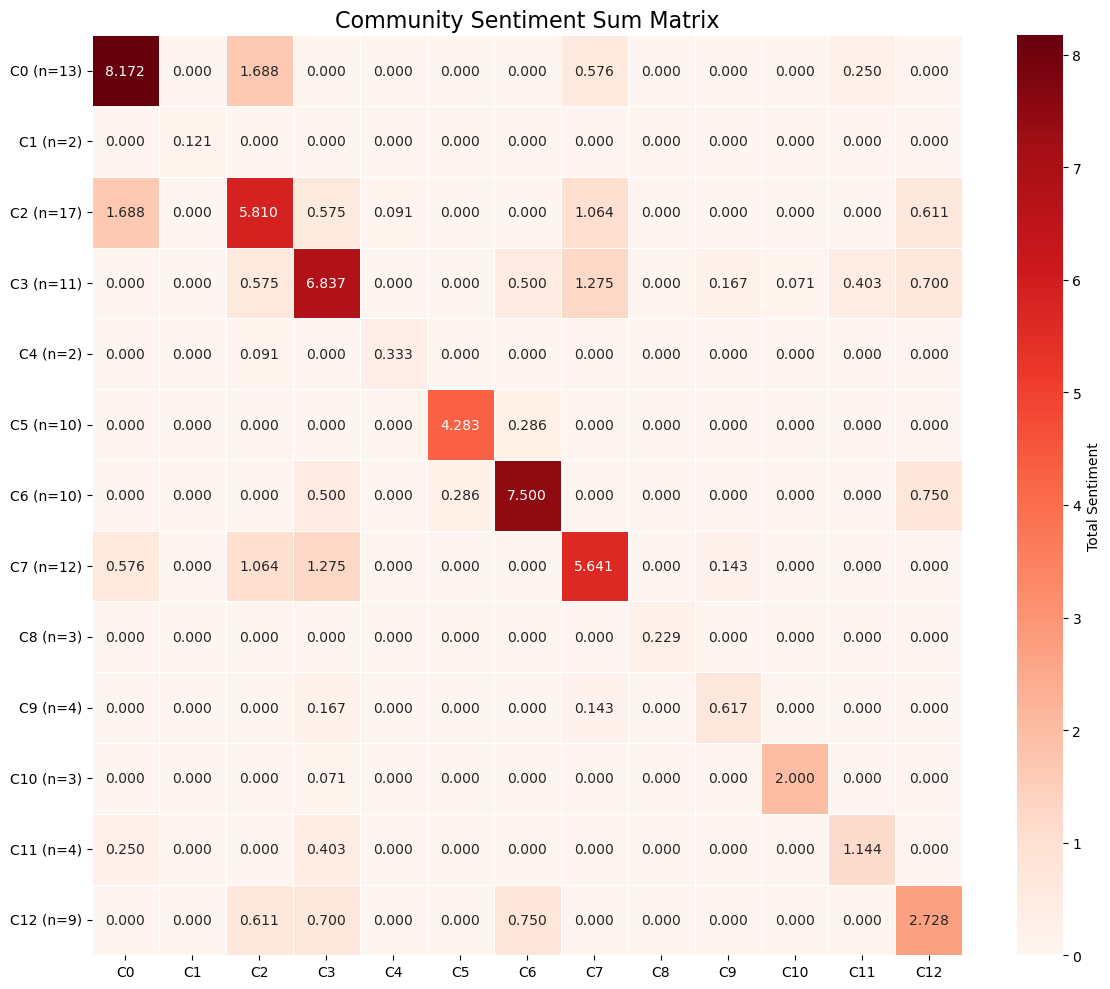

In [16]:
def plot_community_interaction_heatmap(G, partition):
    community_ids = sorted(list(set(partition.values())))
    num_communities = len(community_ids)
    comm_sizes = {cid: list(partition.values()).count(cid) for cid in community_ids}
    
    interaction_matrix = np.zeros((num_communities, num_communities))
    
    for u, v, d in G.edges(data=True):
        weight = d.get('weight', 1.0)
        comm_u = partition[u]
        comm_v = partition[v]
        
        interaction_matrix[comm_u][comm_v] += weight
        if comm_u != comm_v:
            interaction_matrix[comm_v][comm_u] += weight
            
    df_matrix = pd.DataFrame(
        interaction_matrix, 
        index=[f'C{i} (n={comm_sizes[i]})' for i in community_ids],
        columns=[f'C{i}' for i in community_ids]
    )
    
    plt.figure(figsize=(12, 10))
    
    sns.heatmap(df_matrix, annot=True, fmt='.3f', cmap='Reds', 
                linewidths=.5, cbar_kws={'label': 'Total Sentiment'})
    
    plt.title("Community Sentiment Sum Matrix", fontsize=16)
    # plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plot_community_interaction_heatmap(G, partition)

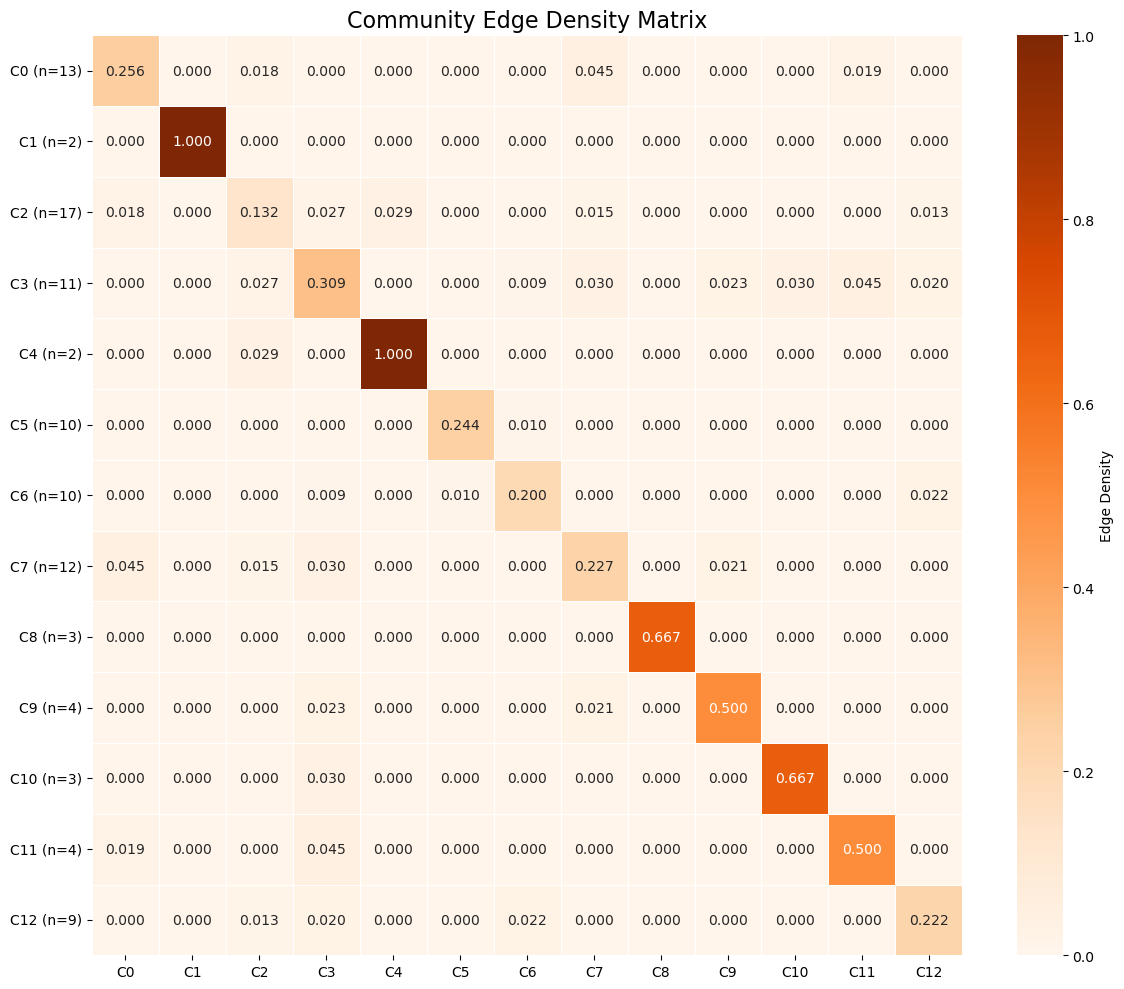

In [17]:
def plot_community_density_heatmap(G, partition):
    community_ids = sorted(list(set(partition.values())))
    num_communities = len(community_ids)
    comm_sizes = {cid: list(partition.values()).count(cid) for cid in community_ids}
    
    edge_count_matrix = np.zeros((num_communities, num_communities))
    for u, v in G.edges():
        comm_u = partition[u]
        comm_v = partition[v]
        
        edge_count_matrix[comm_u][comm_v] += 1
        if comm_u != comm_v:
            edge_count_matrix[comm_v][comm_u] += 1
            
    density_matrix = np.zeros((num_communities, num_communities))
    for i in range(num_communities):
        for j in range(num_communities):
            s_i = comm_sizes[community_ids[i]]
            s_j = comm_sizes[community_ids[j]]
            
            if i == j:
                possible = s_i * (s_i - 1) / 2 if s_i > 1 else 1
            else:
                possible = s_i * s_j
            
            density_matrix[i][j] = edge_count_matrix[i][j] / possible

    df_density = pd.DataFrame(
        density_matrix, 
        index=[f'C{i} (n={comm_sizes[i]})' for i in community_ids],
        columns=[f'C{i}' for i in community_ids]
    )
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(df_density, annot=True, fmt='.3f', cmap='Oranges', 
                linewidths=.5, cbar_kws={'label': 'Edge Density'})
    
    plt.title("Community Edge Density Matrix", fontsize=16)
    plt.tight_layout()
    plt.show()

plot_community_density_heatmap(G, partition)

## Preparations for Gephi
To draw a network in the world map, nodes must possesss latitudes and longitudes to call Geo Layout in Gephi, which fixes nodes positions based on provided locations. The study utilized locations from the geodatos and google. In addition, the study also recorded community division results into nodes' My_Community attribute, in order to color communities in Gephi.
https://www.geodatos.net/en/coordinates/
https://developers.google.com/public-data/docs/canonical/countries_csv

In [ ]:
node_list = []
for node in G.nodes():
        comm_id = partition.get(node, -1) #if not found, -1
        node_list.append({
            'ID': node,             
            'Label': node,
            'My_Community': comm_id
        })
    
df_nodes = pd.DataFrame(node_list)
df_nodes.to_csv("../data/gephi/layer1/node_list.csv", index=False, encoding='utf-8-sig')

In [ ]:
df = pd.read_csv('../data/gephi/layer1/node_list.csv')
geo = pd.read_csv('../data/gephi/geo_states.csv')
df_new = df.merge(geo, left_on='ID', right_on='country', how='left')
df_new.to_csv('../data/gephi/layer1/node_list_with_latlon.csv', index=False)

## Community List
There is a very interesting phenonmenon: US and Iran were divided into the same camp, which violates the political consensus. However, they were connected through brokers rather than their direct relationships.

In [ ]:
# print node labels in each community
community_to_nodes = {}
for node, cid in partition.items():
    community_to_nodes.setdefault(cid, []).append(node)

for cid in sorted(community_to_nodes.keys()):
    labels = sorted(community_to_nodes[cid])
    print(f"Community {cid} (n={len(labels)}):")
    print(", ".join(labels))
    print("-" * 60)

Community 0 (n=13):
Cambodia, DR Congo, Egypt, Ethiopia, Iran, Pakistan, Qatar, Rwanda, Serbia, Somalia, Sri Lanka, Türkiye, United States
------------------------------------------------------------
Community 1 (n=2):
Ukraine, United Kingdom
------------------------------------------------------------
Community 2 (n=17):
Canada, China, Finland, Iceland, India, Israel, Japan, Malaysia, Mongolia, Morocco, New Zealand, Nigeria, Papua New Guinea, South Korea, South Sudan, Thailand, Venezuela
------------------------------------------------------------
Community 3 (n=11):
Belgium, Croatia, Czechia, France, Hungary, Liechtenstein, Luxembourg, Malta, Moldova, Monaco, Montenegro
------------------------------------------------------------
Community 4 (n=2):
Palestine, Portugal
------------------------------------------------------------
Community 5 (n=10):
Argentina, Bahamas, Brazil, Cuba, Dominican Republic, Ecuador, El Salvador, Guatemala, Honduras, Nicaragua
-------------------------------

# Node Identification
Regarding leader identification (Appendix B), France emerges as the dominant hub possessing the highest scores across all four centrality measures. France not only maintains the most connections within the network but also engages extensively with other influential states. In addition, it also governs the flow of cooperation across the entire network in terms of availability and efficiency. Such a node is an Achilles’ heel in this subtly balanced polycentric system. On one hand, it provides shortcuts for global cooperation that would otherwise rely on redundant paths. On the other hand, it represents the most vulnerable point in the network; should it be disrupted, the entire network could be severely destabilized. Therefore, the co-existence of monocentric node and polycentric network reveals the vulnerability of the current interaction landscape. The seemingly paradoxical structure reflects a notable tension in the current world political landscape, with France emerging to improve the low efficiency inherent in the polycentric system, yet simultaneously introducing risk to what was previously a stable and balanced structure.

In [ ]:
# centrality: top 10 nodes for each metric
degree_c = nx.degree_centrality(G)
betweenness_c = nx.betweenness_centrality(G)
closeness_c = nx.closeness_centrality(G)

try:
    eigenvector_c = nx.eigenvector_centrality(G, max_iter=5000)
except nx.PowerIterationFailedConvergence:
    eigenvector_c = nx.eigenvector_centrality_numpy(G)


def print_top10(metric_name, metric_dict):
    top10 = sorted(metric_dict.items(), key=lambda x: x[1], reverse=True)[:10]
    print(f"\n=== Top 10 by {metric_name} ===")
    for rank, (node, score) in enumerate(top10, start=1):
        print(f"{rank:>2}. {node:<25} {score:.3f}")

print_top10("Degree Centrality", degree_c)
print_top10("Betweenness Centrality", betweenness_c)
print_top10("Closeness Centrality", closeness_c)
print_top10("Eigenvector Centrality", eigenvector_c)



=== Top 10 by Degree Centrality ===
 1. France                    0.141
 2. Serbia                    0.101
 3. India                     0.091
 4. United Arab Emirates      0.091
 5. Singapore                 0.081
 6. Belgium                   0.081
 7. Canada                    0.071
 8. Australia                 0.071
 9. Pakistan                  0.061
10. Türkiye                   0.061

=== Top 10 by Betweenness Centrality ===
 1. France                    0.344
 2. Chile                     0.246
 3. Belgium                   0.183
 4. Argentina                 0.158
 5. Serbia                    0.153
 6. Ecuador                   0.142
 7. Australia                 0.135
 8. Palau                     0.131
 9. Brazil                    0.127
10. Senegal                   0.118

=== Top 10 by Closeness Centrality ===
 1. France                    0.305
 2. New Zealand               0.274
 3. Malta                     0.270
 4. Palau                     0.270
 5. Belgium      

To conclude, the positive interaction layer (Figure 3) is characterized by a polycentric system that is inward-cohesive yet outward-sparse, with a monocentric node controlling the entire network. The network is robust overall, relying on redundant cooperation paths yet fragile should its monocentric node be disrupted. 